In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.linalg import block_diag
import csv  # 添加csv模块

Nodal Displacements and Rotations (mm and rad):
Node ID | ux    | uy    | uz    | θx   | θy   | θz
 0    |  0.000 |  0.000 |  0.000 | 0.0000 | 0.0000 | 0.0000
 1    |  0.000 |  0.000 |  0.000 | 0.0000 | 0.0000 | 0.0000
 2    |  0.000 |  0.000 |  0.000 | 0.0000 | 0.0000 | 0.0000
 3    |  0.000 |  0.000 |  0.000 | 0.0000 | 0.0000 | 0.0000
 4    |  0.000 |  0.000 |  0.000 | 0.0000 | 0.0000 | 0.0000
 5    |  0.000 |  0.000 |  0.000 | 0.0000 | 0.0000 | 0.0000
 6    |  0.000 |  0.000 |  0.000 | 0.0000 | 0.0000 | 0.0000
 7    |  0.000 |  0.000 |  0.000 | 0.0000 | 0.0000 | 0.0000
 8    |  0.000 |  0.000 |  0.000 | 0.0000 | 0.0000 | 0.0000
 9    |  0.000 |  0.000 |  0.000 | 0.0000 | 0.0000 | 0.0000
10    |  0.000 |  0.000 |  0.000 | 0.0000 | 0.0000 | 0.0000
11    |  0.000 |  0.000 |  0.000 | 0.0000 | 0.0000 | 0.0000
12    |  2.268 |  0.000 | -0.040 | -0.0000 | 0.0008 | -0.0000
13    |  2.197 |  0.000 | -0.025 | -0.0000 | 0.0006 | -0.0000
14    |  2.148 |  0.000 | -0.029 | -0.0000 | 0.0006 | 0.0

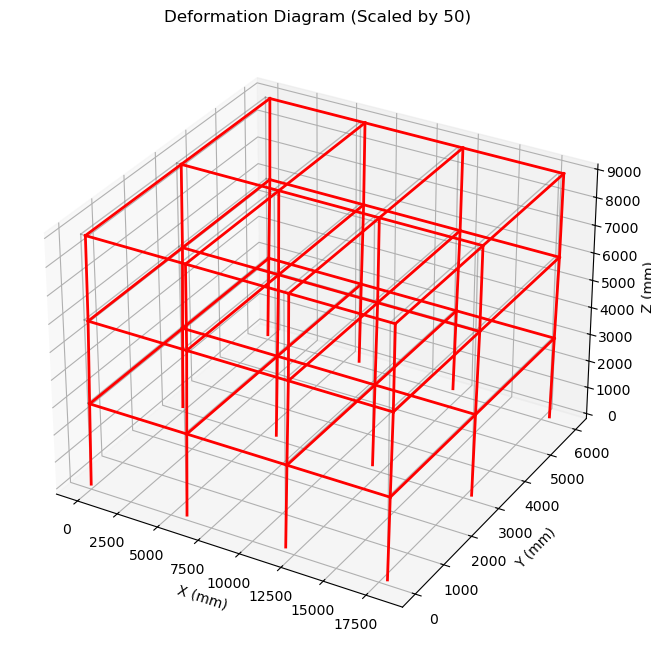


=== GENERATING CSV FILE WITH ALL POINT DISPLACEMENTS ===
Adding internal sampling points every 200mm...
Total unique points to output: 1671
CSV文件 'all_point_displacements_v2.csv' 已保存，包含 1671 个唯一的点

=== CSV文件前10行示例 ===
X(mm), Y(mm), Z(mm), U1(mm), U2(mm), U3(mm), UR1(rad), UR2(rad), UR3(rad), Total_Displacement(mm)
------------------------------------------------------------------------------------------------------------------------
0.0, 0.0, 0.0, 0.000000, 0.000000, 0.000000, 0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000
0.0, 0.0, 200.0, 0.019446, 0.000049, -0.002687, 4.707567e-07, 1.911119e-04, -7.856657e-18, 0.019630
0.0, 0.0, 400.0, 0.075107, 0.000181, -0.005373, 8.381612e-07, 3.621588e-04, -1.571331e-17, 0.075299
0.0, 0.0, 600.0, 0.162971, 0.000377, -0.008060, 1.102213e-06, 5.131406e-04, -2.356997e-17, 0.163171
0.0, 0.0, 800.0, 0.279026, 0.000615, -0.010746, 1.262913e-06, 6.440574e-04, -3.142663e-17, 0.279233
0.0, 0.0, 1000.0, 0.419257, 0.000875, -0.013433, 1.320261e-06, 7.5

In [2]:
# Material properties
E = 2.06e5  # MPa = N/mm²
nu = 0.2
G = E / (2 * (1 + nu))
A = 500 * 500  # mm²
a = 500  # mm
Iy = Iz = a**4 / 12  # mm⁴
J = 0.1406 * a**4  # Torsion constant for square section, mm⁴

# Geometry
Lx = 6000  # mm
Ly = 3000  # mm
Lz = 3000  # mm
nX = 4
nY = 3
nZ = 4
n_nodes = nX * nY * nZ  # 48
n_dof = 6 * n_nodes  # 288
n_floor_dof = nX * nY * 6  # 72 per floor, fixed 72

# Node coordinates
nodes = np.zeros((n_nodes, 3))
node_index = np.zeros((nZ, nY, nX), dtype=int)
idx = 0
for k in range(nZ):
    for j in range(nY):
        for i in range(nX):
            nodes[idx] = [i * Lx, j * Ly, k * Lz]
            node_index[k, j, i] = idx
            idx += 1

# Function to get global DOF indices for an element
def get_dofs(node1, node2):
    dofs = np.zeros(12, dtype=int)
    dofs[0:6] = 6 * node1 + np.arange(6)
    dofs[6:12] = 6 * node2 + np.arange(6)
    return dofs

# Function to build local stiffness matrix (Euler-Bernoulli 3D beam)
def local_stiffness(L, EA, GJ, EIy, EIz):
    K_local = np.zeros((12, 12))
    
    # Axial
    k_axial = EA / L
    K_local[0, 0] = k_axial
    K_local[0, 6] = -k_axial
    K_local[6, 0] = -k_axial
    K_local[6, 6] = k_axial
    
    # Torsion
    k_torsion = GJ / L
    K_local[3, 3] = k_torsion
    K_local[3, 9] = -k_torsion
    K_local[9, 3] = -k_torsion
    K_local[9, 9] = k_torsion
    
    # Bending in y (uy, θz): dofs 1,5,7,11 (0-based)
    a_y = 12 * EIz / L**3
    b_y = 6 * EIz / L**2
    c_y = 4 * EIz / L
    d_y = 2 * EIz / L
    bending_y = np.array([
        [a_y, b_y, -a_y, b_y],
        [b_y, c_y, -b_y, d_y],
        [-a_y, -b_y, a_y, -b_y],
        [b_y, d_y, -b_y, c_y]
    ])
    dofs_y = [1, 5, 7, 11]
    for ii, r in enumerate(dofs_y):
        for jj, c in enumerate(dofs_y):
            K_local[r, c] = bending_y[ii, jj]
    
    # Bending in z (uz, θy): dofs 2,4,8,10 (0-based)
    a_z = 12 * EIy / L**3
    b_z = 6 * EIy / L**2
    c_z = 4 * EIy / L
    d_z = 2 * EIy / L
    bending_z = np.array([
        [a_z, b_z, -a_z, b_z],
        [b_z, c_z, -b_z, d_z],
        [-a_z, -b_z, a_z, -b_z],
        [b_z, d_z, -b_z, c_z]
    ])
    dofs_z = [2, 4, 8, 10]
    for ii, r in enumerate(dofs_z):
        for jj, c in enumerate(dofs_z):
            K_local[r, c] = bending_z[ii, jj]
    
    return K_local

# Global K and F
K = np.zeros((n_dof, n_dof))
F = np.zeros(n_dof)

# Lambda matrices
Lambda_X = np.eye(3)
Lambda_Y = np.array([[0, 1, 0],
                     [1, 0, 0],
                     [0, 0, 1]])
Lambda_Z = np.array([[0, 0, 1],
                     [1, 0, 0],
                     [0, 1, 0]])

# Precompute M for each type (6x6)
M_X = block_diag(Lambda_X, Lambda_X)
M_Y = block_diag(Lambda_Y, Lambda_Y)
M_Z = block_diag(Lambda_Z, Lambda_Z)

# T for each (12x12)
T_X = block_diag(M_X, M_X)
T_Y = block_diag(M_Y, M_Y)
T_Z = block_diag(M_Z, M_Z)

# Element properties
EA = E * A
GJt = G * J  # renamed to avoid conflict
EIy_val = E * Iy
EIz_val = E * Iz

# Loads
p_z = -20  # N/mm downward
w_x = 300  # N/mm in +X

# 1. Columns (Z-direction)
for i in range(nX):
    for j in range(nY):
        for kk in range(nZ - 1):
            n1 = node_index[kk, j, i]
            n2 = node_index[kk + 1, j, i]
            L = Lz
            dofs = get_dofs(n1, n2)
            
            # Local K
            K_l = local_stiffness(L, EA, GJt, EIy_val, EIz_val)
            
            # Transform
            T = T_Z
            K_e = T.T @ K_l @ T
            K[np.ix_(dofs, dofs)] += K_e
            
            # Loads: only if i==0, transverse in y' (global X)
            f_l = np.zeros(12)
            if i == 0:
                p_y = w_x
                f_l[1] = p_y * L / 2   # uy1'
                f_l[7] = p_y * L / 2   # uy2'
                f_l[5] = p_y * L**2 / 12  # θz1'
                f_l[11] = -p_y * L**2 / 12  # θz2'
            
            # Transform F
            f_g = T.T @ f_l
            F[dofs] += f_g

# 2. X-beams
for i in range(nX - 1):
    for j in range(nY):
        for kk in range(1, nZ):  # k=1,2,3 (0-based)
            n1 = node_index[kk, j, i]
            n2 = node_index[kk, j, i + 1]
            L = Lx
            dofs = get_dofs(n1, n2)
            
            K_l = local_stiffness(L, EA, GJt, EIy_val, EIz_val)
            T = T_X
            K_e = T.T @ K_l @ T
            K[np.ix_(dofs, dofs)] += K_e
            
            # Load: p_z in z' (global Z)
            f_l = np.zeros(12)
            f_l[2] = p_z * L / 2   # uz1'
            f_l[8] = p_z * L / 2   # uz2'
            f_l[4] = p_z * L**2 / 12  # θy1'
            f_l[10] = -p_z * L**2 / 12  # θy2'
            
            f_g = T.T @ f_l
            F[dofs] += f_g

# 3. Y-beams
for i in range(nX):
    for j in range(nY - 1):
        for kk in range(1, nZ):
            n1 = node_index[kk, j, i]
            n2 = node_index[kk, j + 1, i]
            L = Ly
            dofs = get_dofs(n1, n2)
            
            K_l = local_stiffness(L, EA, GJt, EIy_val, EIz_val)
            T = T_Y
            K_e = T.T @ K_l @ T
            K[np.ix_(dofs, dofs)] += K_e
            
            # Load: p_z in z' (global Z)
            f_l = np.zeros(12)
            f_l[2] = p_z * L / 2   # uz1'
            f_l[8] = p_z * L / 2   # uz2'
            f_l[4] = p_z * L**2 / 12  # θy1'
            f_l[10] = -p_z * L**2 / 12  # θy2'
            
            f_g = T.T @ f_l
            F[dofs] += f_g

# Boundary conditions: fix bottom floor (k=0)
fixed_nodes = []
for j in range(nY):
    for i in range(nX):
        fixed_nodes.append(node_index[0, j, i])
fixed_dofs = []
for n in fixed_nodes:
    for d in range(6):
        fixed_dofs.append(6 * n + d)
free_dofs = [d for d in range(n_dof) if d not in fixed_dofs]

# Solve
K_ff = K[np.ix_(free_dofs, free_dofs)]
F_f = F[free_dofs]
u_f = np.linalg.solve(K_ff, F_f)
u = np.zeros(n_dof)
u[free_dofs] = u_f

# Nodal displacements and rotations
u_node = u.reshape((n_nodes, 6))  # [ux, uy, uz, θx, θy, θz] per node
print("Nodal Displacements and Rotations (mm and rad):")
print("Node ID | ux    | uy    | uz    | θx   | θy   | θz")
for nid in range(n_nodes):
    k, j, i = np.unravel_index(nid, (nZ, nY, nX))  # Wait, actually since indexing k major
    # But print in order i,j,k or something
    print(f"{nid:2d}    | {u_node[nid,0]:6.3f} | {u_node[nid,1]:6.3f} | {u_node[nid,2]:6.3f} | {u_node[nid,3]:6.4f} | {u_node[nid,4]:6.4f} | {u_node[nid,5]:6.4f}")

# Now, for elements: define list of elements
# Each element: (type, n1, n2, L, Lambda, T)
elements = []

# Columns
for i in range(nX):
    for j in range(nY):
        for kk in range(nZ-1):
            n1 = node_index[kk, j, i]
            n2 = node_index[kk+1, j, i]
            elements.append(('Z', n1, n2, Lz, Lambda_Z, T_Z))

# X-beams
for i in range(nX-1):
    for j in range(nY):
        for kk in range(1, nZ):
            n1 = node_index[kk, j, i]
            n2 = node_index[kk, j, i+1]
            elements.append(('X', n1, n2, Lx, Lambda_X, T_X))

# Y-beams
for i in range(nX):
    for j in range(nY-1):
        for kk in range(1, nZ):
            n1 = node_index[kk, j, i]
            n2 = node_index[kk, j+1, i]
            elements.append(('Y', n1, n2, Ly, Lambda_Y, T_Y))

# For each element, compute and print points every 200mm
print("\nElement outputs (ux, uy, uz, θx, θy, θz) every 200mm along axis:")
print("Note: Outputs are global. Element described by nodes n1->n2.")
for elem_id, (etype, n1, n2, L, Lambda, T) in enumerate(elements):
    print(f"\nElement {elem_id+1} ({etype}): Node {n1} -> Node {n2}, L={L}mm")
    print("s(mm) | ux    | uy    | uz    | θx   | θy   | θz")
    
    # Nodal global u for element
    u_g1 = u_node[n1]
    u_g2 = u_node[n2]
    u_elem_g = np.hstack((u_g1, u_g2))  # 12
    
    # Local nodal dofs
    d_l = T @ u_elem_g
    
    # Hermite derivatives
    def hermite(xi):
        N = np.array([1 - 3*xi**2 + 2*xi**3,
                      xi - 2*xi**2 + xi**3,
                      3*xi**2 - 2*xi**3,
                      -xi**2 + xi**3])
        dN_dxi = np.array([-6*xi + 6*xi**2,
                           1 - 4*xi + 3*xi**2,
                           6*xi - 6*xi**2,
                           -2*xi + 3*xi**2])
        return N, dN_dxi
    
    for s in range(0, int(L) + 1, 200):
        xi = s / L
        N, dN = hermite(xi)
        
        # Local ux, θx linear
        ux_l = (1 - xi) * d_l[0] + xi * d_l[6]
        theta_x_l = (1 - xi) * d_l[3] + xi * d_l[9]
        
        # Local uy, θz
        uy_l = N[0] * d_l[1] + N[1] * L * d_l[5] + N[2] * d_l[7] + N[3] * L * d_l[11]
        d_uy_dxi = dN[0] * d_l[1] + dN[1] * L * d_l[5] + dN[2] * d_l[7] + dN[3] * L * d_l[11]
        theta_z_l = d_uy_dxi / L
        
        # Local uz, θy
        uz_l = N[0] * d_l[2] + N[1] * L * d_l[4] + N[2] * d_l[8] + N[3] * L * d_l[10]
        d_uz_dxi = dN[0] * d_l[2] + dN[1] * L * d_l[4] + dN[2] * d_l[8] + dN[3] * L * d_l[10]
        theta_y_l = d_uz_dxi / L
        
        # Local vectors
        u_l = np.array([ux_l, uy_l, uz_l])
        theta_l = np.array([theta_x_l, theta_y_l, theta_z_l])
        
        # Global
        u_g = Lambda.T @ u_l
        theta_g = Lambda.T @ theta_l
        
        print(f"{s:4d}   | {u_g[0]:6.3f} | {u_g[1]:6.3f} | {u_g[2]:6.3f} | {theta_g[0]:6.4f} | {theta_g[1]:6.4f} | {theta_g[2]:6.4f}")

# Visualization of deformation
scale = 50  # Exaggeration factor, adjust as needed
u_disp = u_node[:, :3]  # ux, uy, uz
nodes_def = nodes + scale * u_disp

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot original structure (gray lines)
for elem in elements:
    _, n1, n2, _, _, _ = elem
    ax.plot([nodes[n1, 0], nodes[n2, 0]],
            [nodes[n1, 1], nodes[n2, 1]],
            [nodes[n1, 2], nodes[n2, 2]], 'gray', alpha=0.5, linewidth=1)

# Plot deformed structure (red lines)
for elem in elements:
    _, n1, n2, _, _, _ = elem
    ax.plot([nodes_def[n1, 0], nodes_def[n2, 0]],
            [nodes_def[n1, 1], nodes_def[n2, 1]],
            [nodes_def[n1, 2], nodes_def[n2, 2]], 'red', linewidth=2)

ax.set_xlabel('X (mm)')
ax.set_ylabel('Y (mm)')
ax.set_zlabel('Z (mm)')
ax.set_title('Deformation Diagram (Scaled by 50)')
plt.show()
# ========== CREATE CSV OUTPUT FOR ALL POINTS ==========
print("\n=== GENERATING CSV FILE WITH ALL POINT DISPLACEMENTS ===")

# 使用字典存储点，键为坐标(四舍五入到0.1mm)，值为点的信息
point_dict = {}

# 首先添加所有节点
for nid in range(n_nodes):
    x, y, z = nodes[nid]
    key = (round(x, 1), round(y, 1), round(z, 1))  # 四舍五入到0.1mm
    ux, uy, uz, θx, θy, θz = u_node[nid]
    total_disp = np.sqrt(ux**2 + uy**2 + uz**2)
    
    point_dict[key] = {
        'x': x,
        'y': y, 
        'z': z,
        'ux': ux,
        'uy': uy,
        'uz': uz,
        'θx': θx,
        'θy': θy,
        'θz': θz,
        'total_disp': total_disp
    }

# 然后添加元素内部采样点（每隔200mm）
print("Adding internal sampling points every 200mm...")
for elem_id, (etype, n1, n2, L, Lambda, T) in enumerate(elements):
    # 节点全局坐标
    x1, y1, z1 = nodes[n1]
    x2, y2, z2 = nodes[n2]
    
    # 获取节点位移
    u_g1 = u_node[n1]
    u_g2 = u_node[n2]
    u_elem_g = np.hstack((u_g1, u_g2))
    
    # 局部坐标系下的节点位移
    d_l = T @ u_elem_g
    
    # Hermite插值函数
    def hermite(xi):
        N = np.array([1 - 3*xi**2 + 2*xi**3,
                      xi - 2*xi**2 + xi**3,
                      3*xi**2 - 2*xi**3,
                      -xi**2 + xi**3])
        dN_dxi = np.array([-6*xi + 6*xi**2,
                           1 - 4*xi + 3*xi**2,
                           6*xi - 6*xi**2,
                           -2*xi + 3*xi**2])
        return N, dN_dxi
    
    # 采样点（包括起点和终点，但我们会用坐标去重）
    sample_distances = np.arange(0, int(L) + 1, 200)
    sample_distances = sample_distances[sample_distances <= L]  # 确保不超过长度
    
    for s in sample_distances:
        xi = s / L if L > 0 else 0
        
        # 计算全局坐标（线性插值）
        x = x1 + xi * (x2 - x1)
        y = y1 + xi * (y2 - y1)
        z = z1 + xi * (z2 - z1)
        
        key = (round(x, 1), round(y, 1), round(z, 1))  # 四舍五入到0.1mm
        
        # 如果这个点已经存在，跳过（避免重复）
        if key in point_dict:
            continue
        
        # 使用Hermite插值计算局部位移
        N, dN = hermite(xi)
        
        # 局部坐标系下的位移
        # 轴向位移和扭转
        ux_l = (1 - xi) * d_l[0] + xi * d_l[6]
        theta_x_l = (1 - xi) * d_l[3] + xi * d_l[9]
        
        # Y方向位移和转角
        uy_l = N[0] * d_l[1] + N[1] * L * d_l[5] + N[2] * d_l[7] + N[3] * L * d_l[11]
        d_uy_dxi = dN[0] * d_l[1] + dN[1] * L * d_l[5] + dN[2] * d_l[7] + dN[3] * L * d_l[11]
        theta_z_l = d_uy_dxi / L
        
        # Z方向位移和转角
        uz_l = N[0] * d_l[2] + N[1] * L * d_l[4] + N[2] * d_l[8] + N[3] * L * d_l[10]
        d_uz_dxi = dN[0] * d_l[2] + dN[1] * L * d_l[4] + dN[2] * d_l[8] + dN[3] * L * d_l[10]
        theta_y_l = d_uz_dxi / L
        
        # 局部位移向量
        u_l = np.array([ux_l, uy_l, uz_l])
        theta_l = np.array([theta_x_l, theta_y_l, theta_z_l])
        
        # 转换到全局坐标系
        u_g = Lambda.T @ u_l
        theta_g = Lambda.T @ theta_l
        
        total_disp = np.sqrt(u_g[0]**2 + u_g[1]**2 + u_g[2]**2)
        
        point_dict[key] = {
            'x': x,
            'y': y,
            'z': z,
            'ux': u_g[0],
            'uy': u_g[1],
            'uz': u_g[2],
            'θx': theta_g[0],
            'θy': theta_g[1],
            'θz': theta_g[2],
            'total_disp': total_disp
        }

# 将字典转换为列表并排序（按x, y, z坐标）
sorted_points = sorted(point_dict.values(), key=lambda p: (p['x'], p['y'], p['z']))

print(f"Total unique points to output: {len(sorted_points)}")

# 保存到CSV文件
import csv

csv_filename = 'all_point_displacements_v2.csv'
with open(csv_filename, 'w', newline='') as csvfile:
    fieldnames = ['X', 'Y', 'Z', 'U1', 'U2', 'U3', 'UR1', 'UR2', 'UR3', 'Total_Displacement']
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    
    writer.writeheader()
    for point in sorted_points:
        writer.writerow({
            'X': point['x'],
            'Y': point['y'],
            'Z': point['z'],
            'U1': point['ux'],
            'U2': point['uy'],
            'U3': point['uz'],
            'UR1': point['θx'],
            'UR2': point['θy'],
            'UR3': point['θz'],
            'Total_Displacement': point['total_disp']
        })

print(f"CSV文件 '{csv_filename}' 已保存，包含 {len(sorted_points)} 个唯一的点")

# 显示前10个点作为示例
print("\n=== CSV文件前10行示例 ===")
print("X(mm), Y(mm), Z(mm), U1(mm), U2(mm), U3(mm), UR1(rad), UR2(rad), UR3(rad), Total_Displacement(mm)")
print("-" * 120)
for i, point in enumerate(sorted_points[:10]):
    print(f"{point['x']:.1f}, {point['y']:.1f}, {point['z']:.1f}, "
          f"{point['ux']:.6f}, {point['uy']:.6f}, {point['uz']:.6f}, "
          f"{point['θx']:.6e}, {point['θy']:.6e}, {point['θz']:.6e}, "
          f"{point['total_disp']:.6f}")